In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
import torch
import sklearn

In [ ]:
df_true = pd.read_csv("./database/True.csv")
df_fake = pd.read_csv("./database/Fake.csv")

# 1 - true, 0 - fake
df_true["label"] = 1
df_fake["label"] = 0

df = pd.concat([df_true, df_fake])
df.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [3]:
# No empty strings
print(df.info(), len(df))

<class 'pandas.DataFrame'>
Index: 44898 entries, 0 to 23480
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
dtypes: int64(1), str(4)
memory usage: 2.1 MB
None 44898


In [4]:
# Near 50/50
len(df_true), len(df_fake)

(21417, 23481)

In [ ]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

class_counts = df['label'].value_counts()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\yurck\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


label
0    23481
1    21417
Name: count, dtype: int64

C:\Users\yurck\AppData\Local\Temp\ipykernel_9956\1549962234.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="label", palette=['#e74c3c', '#2ecc71'])


<function matplotlib.pyplot.show(close=None, block=None)>

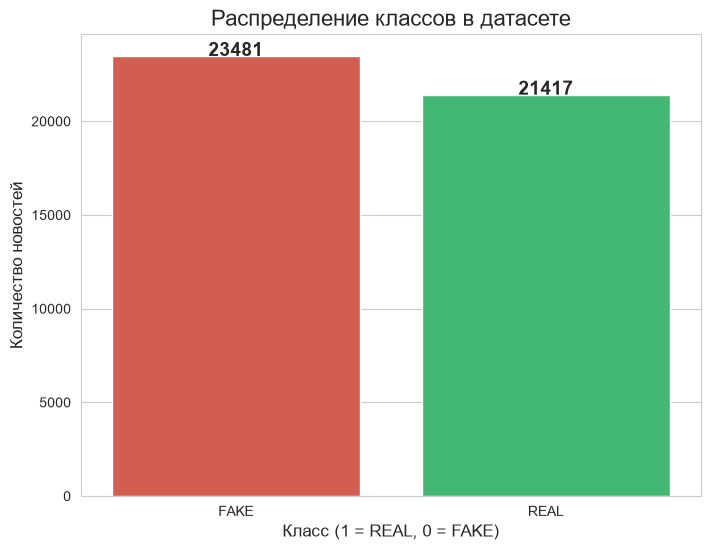

In [ ]:
# class distribution chart
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

ax = sns.countplot(data=df, x="label", palette=['#e74c3c', '#2ecc71'])

for i, v in enumerate(class_counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontsize=14, fontweight='bold')
    
plt.title("Распределение классов в датасете", fontsize=16)
plt.xlabel("Класс (1 = REAL, 0 = FAKE)", fontsize=12)
plt.ylabel("Количество новостей", fontsize=12)
plt.xticks([1,0], ['REAL', 'FAKE'])
plt.show

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\yurck\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\yurck\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


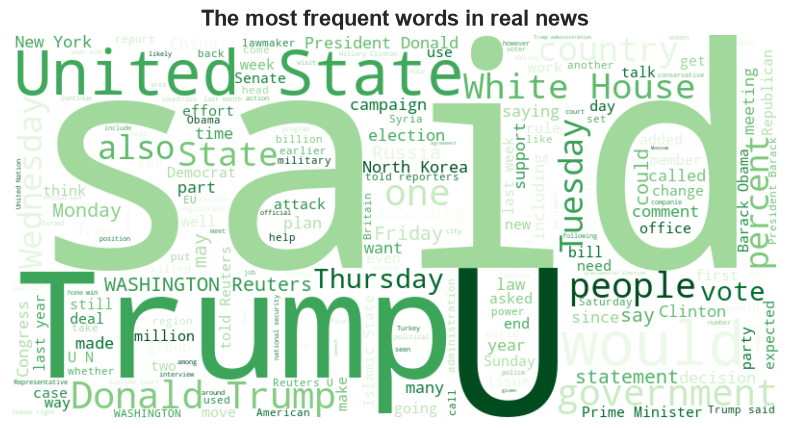

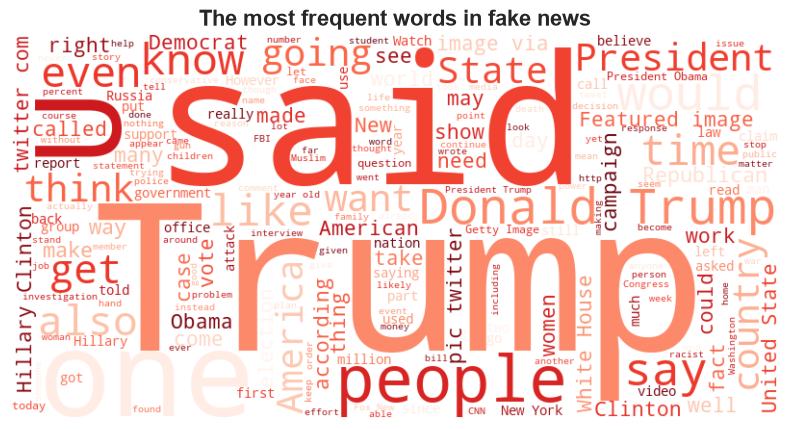

In [24]:
from nltk.corpus import stopwords

nltk.download('stopwords')
nltk.download('punkt')
from wordcloud import WordCloud

stop_words = set(stopwords.words('english'))

# word clouds
def create_wordcloud(text_data, title, color):
    # combining all texts in one string
    all_text = ' '.join(text_data)
    
    # create cloud 
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=color,
        max_words=200,
        stopwords=stop_words
    ).generate(all_text)

    # visualize
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16, fontweight='bold')
    plt.show()
    
# cloud for real news
real_texts = df[df['label'] == 1]['text']
create_wordcloud(real_texts, 'The most frequent words in real news', 'Greens')

# cloud for fake news
real_texts = df[df['label'] == 0]['text']
create_wordcloud(real_texts, 'The most frequent words in fake news', 'Reds')
    

In [29]:
df.to_csv('database/сlear_file.csv', index=False, encoding='utf-8')
